In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/intent-chatbot/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/intent-chatbot/models', exist_ok=True)
print("Folders created!")

Mounted at /content/drive
Folders created!


In [ ]:
!pip install datasets -q
print("Done!")

Done!


In [ ]:
from datasets import load_dataset
import pandas as pd

# Load Banking77 using parquet format directly
banking = load_dataset("legacy-datasets/banking77")

banking_train = pd.DataFrame(banking['train'])
banking_test = pd.DataFrame(banking['test'])

# Rename columns
banking_train.columns = ['text', 'intent']
banking_test.columns = ['text', 'intent']

# Add source column
banking_train['source'] = 'banking77'
banking_test['source'] = 'banking77'

print("Banking77 Train:", len(banking_train))
print("Banking77 Test:", len(banking_test))
print(banking_train.head(3))

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/298k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/93.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

Banking77 Train: 10003
Banking77 Test: 3080
                                                text  intent     source
0                     I am still waiting on my card?      11  banking77
1  What can I do if my card still hasn't arrived ...      11  banking77
2  I have been waiting over a week. Is the card s...      11  banking77


In [ ]:
# Load CLINC150 - using 'small' split (manageable size)
clinc = load_dataset("clinc_oos", "small")

clinc_train = pd.DataFrame(clinc['train'])
clinc_test = pd.DataFrame(clinc['test'])

# Rename columns
clinc_train.columns = ['text', 'intent']
clinc_test.columns = ['text', 'intent']

clinc_train['source'] = 'clinc150'
clinc_test['source'] = 'clinc150'

print("CLINC150 Train:", len(clinc_train))
print("CLINC150 Test:", len(clinc_test))
print(clinc_train.head(3))

README.md: 0.00B [00:00, ?B/s]

small/train-00000-of-00001.parquet:   0%|          | 0.00/172k [00:00<?, ?B/s]

small/validation-00000-of-00001.parquet:   0%|          | 0.00/77.8k [00:00<?, ?B/s]

small/test-00000-of-00001.parquet:   0%|          | 0.00/136k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3100 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5500 [00:00<?, ? examples/s]

CLINC150 Train: 7600
CLINC150 Test: 5500
                                                text  intent    source
0  can you walk me through setting up direct depo...     108  clinc150
1                 i want to switch to direct deposit     108  clinc150
2                       set up direct deposit for me     108  clinc150


In [ ]:
print("Banking77 intent dtype:", banking_train['intent'].dtype)
print("CLINC150 intent dtype:", clinc_train['intent'].dtype)

print("\nBanking77 sample intents:", banking_train['intent'].unique()[:5])
print("CLINC150 sample intents:", clinc_train['intent'].unique()[:5])

Banking77 intent dtype: int64
CLINC150 intent dtype: int64

Banking77 sample intents: [11 13 32 17 34]
CLINC150 sample intents: [108  62  14  26 104]


In [ ]:
# Banking77 uses numeric labels — convert to string intent names
banking_labels = banking['train'].features['label'].names
print("Banking77 intent names sample:", banking_labels[:5])

# Map numeric labels to string names
banking_train['intent'] = banking_train['intent'].map(lambda x: banking_labels[x])
banking_test['intent'] = banking_test['intent'].map(lambda x: banking_labels[x])

print("\nAfter mapping:")
print(banking_train.head(3))

Banking77 intent names sample: ['activate_my_card', 'age_limit', 'apple_pay_or_google_pay', 'atm_support', 'automatic_top_up']

After mapping:
                                                text        intent     source
0                     I am still waiting on my card?  card_arrival  banking77
1  What can I do if my card still hasn't arrived ...  card_arrival  banking77
2  I have been waiting over a week. Is the card s...  card_arrival  banking77


In [ ]:
clinc_labels = clinc['train'].features['intent'].names
print("CLINC150 intent names sample:", clinc_labels[:5])

clinc_train['intent'] = clinc_train['intent'].map(lambda x: clinc_labels[x])
clinc_test['intent'] = clinc_test['intent'].map(lambda x: clinc_labels[x])

print("\nAfter mapping:")
print(clinc_train.head(3))

CLINC150 intent names sample: ['restaurant_reviews', 'nutrition_info', 'account_blocked', 'oil_change_how', 'time']

After mapping:
                                                text          intent    source
0  can you walk me through setting up direct depo...  direct_deposit  clinc150
1                 i want to switch to direct deposit  direct_deposit  clinc150
2                       set up direct deposit for me  direct_deposit  clinc150


In [ ]:
banking_intents = set(banking_train['intent'].unique())
clinc_intents = set(clinc_train['intent'].unique())

overlap = banking_intents.intersection(clinc_intents)
print("Overlapping intents:", len(overlap))
print(overlap)

Overlapping intents: 1
{'exchange_rate'}


In [ ]:
# Remove 'exchange_rate' from CLINC150 since Banking77 already has it
clinc_train = clinc_train[clinc_train['intent'] != 'exchange_rate']
clinc_test = clinc_test[clinc_test['intent'] != 'exchange_rate']

print("CLINC150 after removing overlap:")
print("Train:", len(clinc_train))
print("Test:", len(clinc_test))

# Merge both datasets
train_df = pd.concat([banking_train, clinc_train], ignore_index=True)
test_df = pd.concat([banking_test, clinc_test], ignore_index=True)

print("\nCombined Train size:", len(train_df))
print("Combined Test size:", len(test_df))
print("Total unique intents:", train_df['intent'].nunique())
print("\nSample rows:")
print(train_df.sample(5))

CLINC150 after removing overlap:
Train: 7550
Test: 5470

Combined Train size: 17553
Combined Test size: 8550
Total unique intents: 227

Sample rows:
                                                 text                  intent  \
9509   I withdrew money and got a fee, please explain  cash_withdrawal_charge   
17473                 how many sides are in a hexagon                     oos   
14455                      that statement was correct                     yes   
10910           i am hoping to apply for an amex card                new_card   
15966                 what is the time zone of france                timezone   

          source  
9509   banking77  
17473   clinc150  
14455   clinc150  
10910   clinc150  
15966   clinc150  


Min samples per intent: 35
Max samples per intent: 187
Mean samples per intent: 77.33


/tmp/ipykernel_2199/3817166125.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


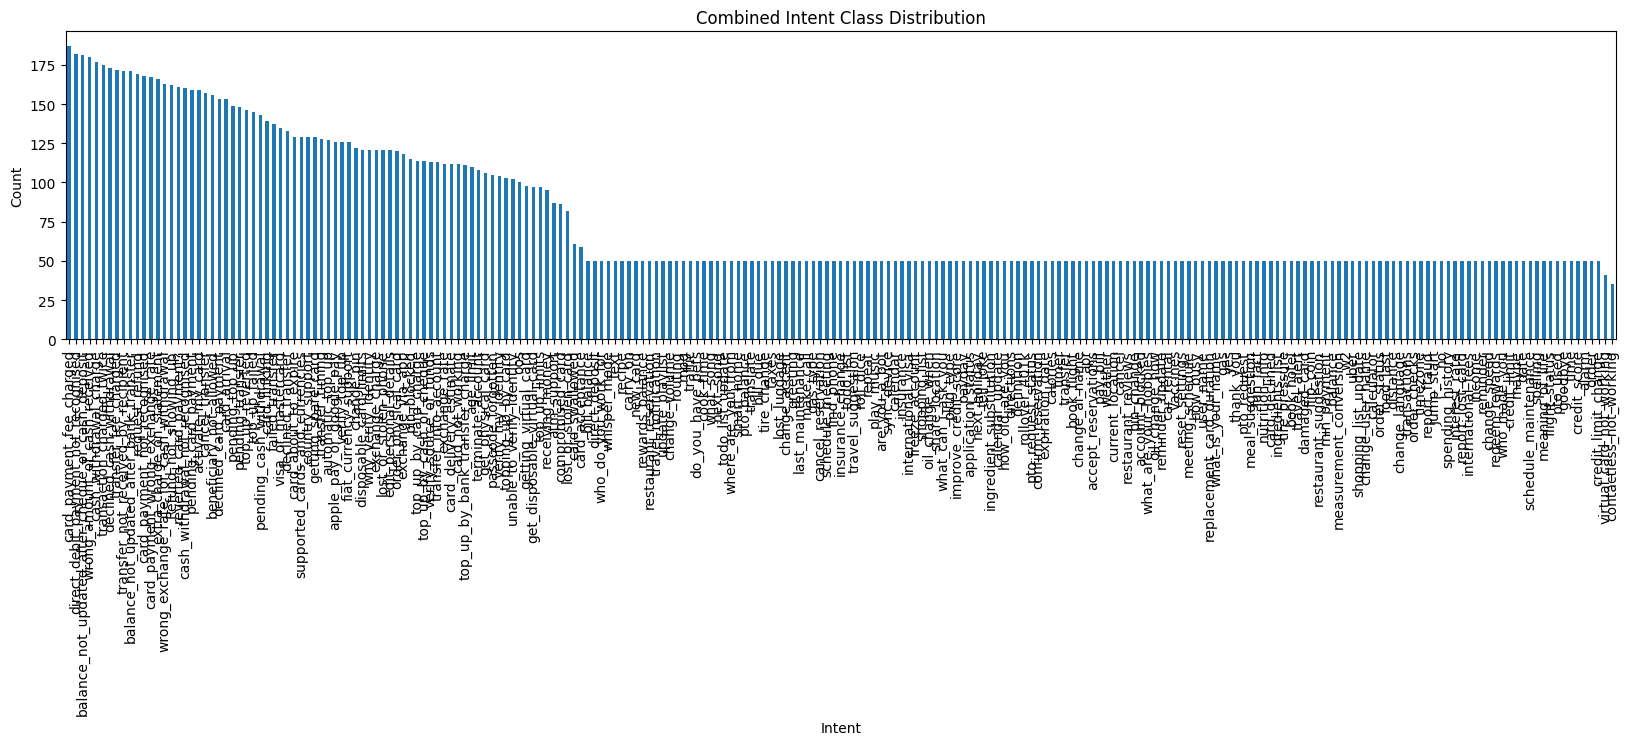

In [ ]:
import matplotlib.pyplot as plt

class_counts = train_df['intent'].value_counts()
print("Min samples per intent:", class_counts.min())
print("Max samples per intent:", class_counts.max())
print("Mean samples per intent:", round(class_counts.mean(), 2))

plt.figure(figsize=(20, 4))
class_counts.plot(kind='bar')
plt.title("Combined Intent Class Distribution")
plt.xlabel("Intent")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df['label'] = le.fit_transform(train_df['intent'])
test_df['label'] = le.transform(test_df['intent'])

print("Total classes:", len(le.classes_))
print("Sample encoding:")
for i in range(5):
    print(f"  {le.classes_[i]} → {i}")

Total classes: 227
Sample encoding:
  Refund_not_showing_up → 0
  accept_reservations → 1
  account_blocked → 2
  activate_my_card → 3
  age_limit → 4


In [ ]:
import pickle

# Save label encoder to Drive
with open('/content/drive/MyDrive/intent-chatbot/data/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("Label encoder saved!")

Label encoder saved!


In [ ]:
import re
import nltk
nltk.download('stopwords', quiet=True)

def clean_text(text):
    text = text.lower()                          # lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)     # remove special chars
    text = re.sub(r'\s+', ' ', text).strip()     # remove extra spaces
    return text

train_df['text'] = train_df['text'].apply(clean_text)
test_df['text'] = test_df['text'].apply(clean_text)

print("Sample cleaned text:")
print(train_df[['text', 'intent']].head(5))

Sample cleaned text:
                                                text        intent
0                      i am still waiting on my card  card_arrival
1  what can i do if my card still hasnt arrived a...  card_arrival
2  i have been waiting over a week is the card st...  card_arrival
3  can i track my card while it is in the process...  card_arrival
4  how do i know if i will get my card or if it i...  card_arrival


In [ ]:
from sklearn.model_selection import train_test_split

# Split train into train + validation (90/10)
train_final, val_df = train_test_split(
    train_df,
    test_size=0.1,
    random_state=42,
    stratify=train_df['label']
)

print("Final Train size:", len(train_final))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Final Train size: 15797
Validation size: 1756
Test size: 8550


In [ ]:
train_final.to_csv('/content/drive/MyDrive/intent-chatbot/data/train.csv', index=False)
val_df.to_csv('/content/drive/MyDrive/intent-chatbot/data/val.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/intent-chatbot/data/test.csv', index=False)

print("All datasets saved to Drive!")
print("Train:", len(train_final))
print("Val:", len(val_df))
print("Test:", len(test_df))

All datasets saved to Drive!
Train: 15797
Val: 1756
Test: 8550


In [ ]:
import os

files = [
    '/content/drive/MyDrive/intent-chatbot/data/train.csv',
    '/content/drive/MyDrive/intent-chatbot/data/val.csv',
    '/content/drive/MyDrive/intent-chatbot/data/test.csv',
    '/content/drive/MyDrive/intent-chatbot/data/label_encoder.pkl'
]

for f in files:
    exists = os.path.exists(f)
    print(f"{'✅' if exists else '❌'} {f}")

✅ /content/drive/MyDrive/intent-chatbot/data/train.csv
✅ /content/drive/MyDrive/intent-chatbot/data/val.csv
✅ /content/drive/MyDrive/intent-chatbot/data/test.csv
✅ /content/drive/MyDrive/intent-chatbot/data/label_encoder.pkl
